VICON DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display plots inline
%matplotlib inline


In [2]:
# Path to your VICON CSV file
# Load the CSV file
df_vicon = pd.read_csv("/home/cpsl/px4_ws/data2_26.894khz_log43/csv_out/vicon__x500_7__x500_7.csv")

# Show basic info
print("Data summary:")
df_vicon.info()

# Display first few rows
df_vicon.head()


Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8357 entries, 0 to 8356
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   t                        8357 non-null   float64
 1   t_rel                    8357 non-null   float64
 2   header.stamp             8357 non-null   float64
 3   header.frame_id          8357 non-null   object 
 4   header.stamp.sec         8357 non-null   int64  
 5   header.stamp.nanosec     8357 non-null   int64  
 6   child_frame_id           8357 non-null   object 
 7   transform.translation.x  8357 non-null   float64
 8   transform.translation.y  8357 non-null   float64
 9   transform.translation.z  8357 non-null   float64
 10  transform.rotation.x     8357 non-null   float64
 11  transform.rotation.y     8357 non-null   float64
 12  transform.rotation.z     8357 non-null   float64
 13  transform.rotation.w     8357 non-null   float64
dtypes: float64

,t,t_rel,header.stamp,header.frame_id,header.stamp.sec,header.stamp.nanosec,child_frame_id,transform.translation.x,transform.translation.y,transform.translation.z,transform.rotation.x,transform.rotation.y,transform.rotation.z,transform.rotation.w
0,1.760993e+09,0.000000,1.760993e+09,vicon/world,1760992869,439070943,vicon/x500_7/x500_7,0.077514,0.052741,0.839319,0.002008,-0.011259,0.679265,0.733804
1,1.760993e+09,0.010007,1.760993e+09,vicon/world,1760992869,448743022,vicon/x500_7/x500_7,0.077370,0.052758,0.839375,0.001654,-0.011525,0.678774,0.734255
2,1.760993e+09,0.019866,1.760993e+09,vicon/world,1760992869,458686740,vicon/x500_7/x500_7,0.077290,0.052638,0.839475,0.002701,-0.012079,0.678743,0.734271
3,1.760993e+09,0.029577,1.760993e+09,vicon/world,1760992869,468894208,vicon/x500_7/x500_7,0.077189,0.052643,0.839538,0.002166,-0.012137,0.678912,0.734116
4,1.760993e+09,0.040358,1.760993e+09,vicon/world,1760992869,479357064,vicon/x500_7/x500_7,0.077057,0.052653,0.839565,0.002135,-0.012411,0.678697,0.734311


In [3]:
# ---------------- 1) Positions: keep ENU and add NED ----------------
# ENU from Vicon
x_e = df_vicon["transform.translation.x"].to_numpy()  # East
y_e = df_vicon["transform.translation.y"].to_numpy()  # North
z_e = df_vicon["transform.translation.z"].to_numpy()  # Up

# Save ENU positions explicitly
df_vicon["pos_east_enu"]   = x_e
df_vicon["pos_north_enu"]  = y_e
df_vicon["pos_up_enu"]     = z_e

# Convert ENU -> NED (world flip)
x_n = y_e         # North
y_n = x_e         # East
z_n = -z_e        # Down

df_vicon["pos_north_ned"] = x_n
df_vicon["pos_east_ned"]  = y_n
df_vicon["pos_down_ned"]  = z_n

print("✅ Stored positions in both ENU and NED frames.")

✅ Stored positions in both ENU and NED frames.


In [4]:
# ---------------- 2) Quaternions -> rotation matrix (vectorized) ----------------
# Expecting Vicon quaternion as orientation of body (FLU) in world (ENU): [x,y,z,w]
qx = df_vicon["transform.rotation.x"].to_numpy()
qy = df_vicon["transform.rotation.y"].to_numpy()
qz = df_vicon["transform.rotation.z"].to_numpy()
qw = df_vicon["transform.rotation.w"].to_numpy()

# Normalize (robustness)
norm = np.sqrt(qx*qx + qy*qy + qz*qz + qw*qw)
norm[norm == 0] = 1.0
qx, qy, qz, qw = qx/norm, qy/norm, qz/norm, qw/norm

def quat_array_to_rotmat(qx, qy, qz, qw):
    """
    Vectorized quaternion -> rotation matrix (N,3,3).
    Returns R_enu: rotation mapping body(FLU) vectors to world(ENU) vectors.
    """
    x, y, z, w = qx, qy, qz, qw
    xx, yy, zz = x*x, y*y, z*z
    xy, xz, yz = x*y, x*z, y*z
    wx, wy, wz = w*x, w*y, w*z

    R = np.empty((x.shape[0], 3, 3), dtype=float)
    R[:,0,0] = 1 - 2*(yy+zz)
    R[:,0,1] = 2*(xy - wz)
    R[:,0,2] = 2*(xz + wy)

    R[:,1,0] = 2*(xy + wz)
    R[:,1,1] = 1 - 2*(xx+zz)
    R[:,1,2] = 2*(yz - wx)

    R[:,2,0] = 2*(xz - wy)
    R[:,2,1] = 2*(yz + wx)
    R[:,2,2] = 1 - 2*(xx+yy)
    return R

R_enu = quat_array_to_rotmat(qx, qy, qz, qw)  # (N,3,3), body FLU -> world ENU

In [5]:
# ---------------- 3) Euler angles in ENU (FLU body) ----------------
# ZYX Tait–Bryan (yaw Z, pitch Y, roll X) from rotation mapping body->world
pitch_enu = np.arcsin(np.clip(-R_enu[:,2,0], -1.0, 1.0))
roll_enu  = np.arctan2(R_enu[:,2,1], R_enu[:,2,2])
yaw_enu   = np.arctan2(R_enu[:,1,0], R_enu[:,0,0])

df_vicon["roll_enu_deg"]  = np.degrees(roll_enu)
df_vicon["pitch_enu_deg"] = np.degrees(pitch_enu)
df_vicon["yaw_enu_deg"]   = np.degrees(yaw_enu)


In [6]:
# ---------------- 4) Euler angles in NED (FRD body) ----------------
# Fixed world flip: ENU -> NED
Cw = np.array([[0, 1, 0],    # x_N = y_E, y_N = x_E, z_N = -z_E
               [1, 0, 0],
               [0, 0,-1]], dtype=float)
# Fixed body flip: FLU -> FRD (roll 180°)
Cb = np.array([[ 1, 0, 0],
               [ 0,-1, 0],
               [ 0, 0,-1]], dtype=float)

# R_ned maps body(FRD) -> world(NED)
# R_ned = Cw * (R_enu) * Cb^T
R_ned = np.einsum('ij,njk,kl->nil', Cw, R_enu, Cb.T)  # (N,3,3)

pitch_ned = np.arcsin(np.clip(-R_ned[:,2,0], -1.0, 1.0))
roll_ned  = np.arctan2(R_ned[:,2,1], R_ned[:,2,2])
yaw_ned   = np.arctan2(R_ned[:,1,0], R_ned[:,0,0])

df_vicon["roll_ned_deg"]  = np.degrees(roll_ned)
df_vicon["pitch_ned_deg"] = np.degrees(pitch_ned)
df_vicon["yaw_ned_deg"]   = np.degrees(yaw_ned)

print("✅ Computed Euler angles in both ENU(FLU) and NED(FRD).")
print(df_vicon[[
    "pos_east_enu","pos_north_enu","pos_up_enu",
    "pos_north_ned","pos_east_ned","pos_down_ned",
    "roll_enu_deg","pitch_enu_deg","yaw_enu_deg",
    "roll_ned_deg","pitch_ned_deg","yaw_ned_deg"
]].head())

✅ Computed Euler angles in both ENU(FLU) and NED(FRD).
   pos_east_enu  pos_north_enu  pos_up_enu  pos_north_ned  pos_east_ned  \
0      0.077514       0.052741    0.839319       0.052741      0.077514   
1      0.077370       0.052758    0.839375       0.052758      0.077370   
2      0.077290       0.052638    0.839475       0.052638      0.077290   
3      0.077189       0.052643    0.839538       0.052643      0.077189   
4      0.077057       0.052653    0.839565       0.052653      0.077057   

   pos_down_ned  roll_enu_deg  pitch_enu_deg  yaw_enu_deg  roll_ned_deg  \
0     -0.839319     -0.707630      -1.103080    85.586266     -0.707630   
1     -0.839375     -0.757434      -1.098496    85.510220     -0.757434   
2     -0.839475     -0.712396      -1.226550    85.506770     -0.712396   
3     -0.839538     -0.762194      -1.189573    85.533344     -0.762194   
4     -0.839565     -0.785823      -1.210466    85.500480     -0.785823   

   pitch_ned_deg  yaw_ned_deg  
0       1.1

[NED] First 10s means — North: 0.039 m, East: 0.078 m, Down: -0.846 m


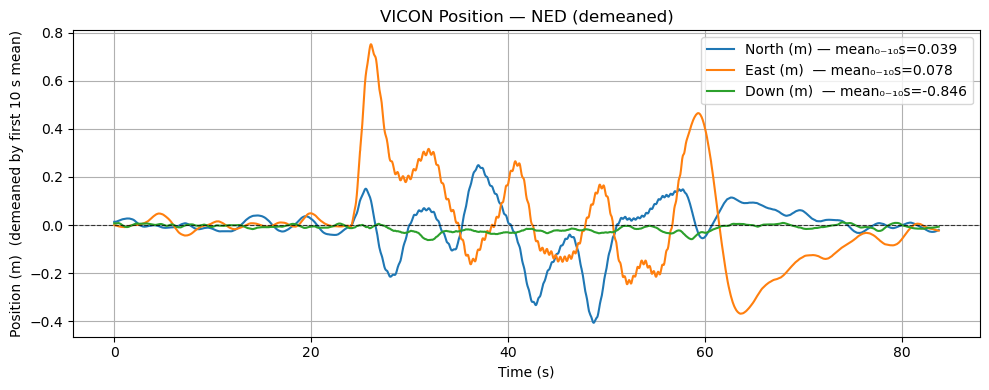

[ENU] First 10s means — East: 0.078 m, North: 0.039 m, Up: 0.846 m


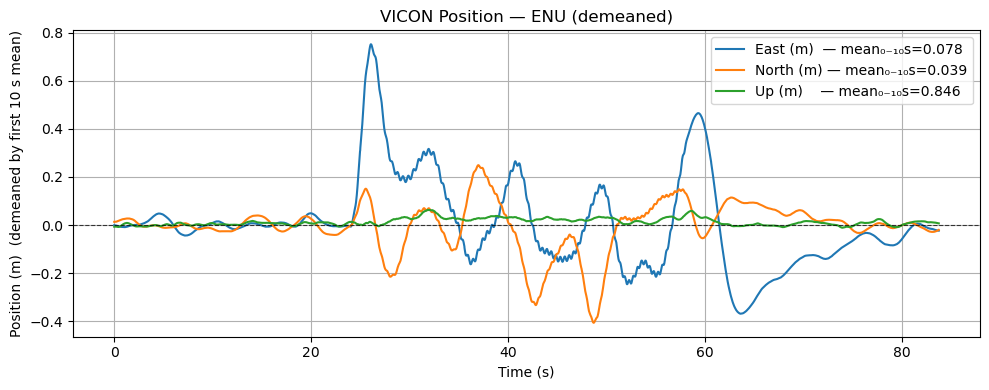

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---- time base ----
time_s = df_vicon["t_rel"].to_numpy()

def demean_first_10s(t, a):
    """Return (a_demeaned, mean_0_10s) using the first 10 s window."""
    t0 = float(t[0])
    mask10 = (t - t0) <= 10.0
    if not np.any(mask10):  # fallback if shorter than 10 s
        mask10 = np.ones_like(t, dtype=bool)
    m = float(np.nanmean(a[mask10]))
    return a - m, m

# =========================== NED plot ===========================
# Use new names if present; fall back to old ones if not.
north = df_vicon.get("pos_north_ned", df_vicon.get("pos_north")).to_numpy()
east  = df_vicon.get("pos_east_ned",  df_vicon.get("pos_east")).to_numpy()
down  = df_vicon.get("pos_down_ned",  df_vicon.get("pos_down")).to_numpy()

north_dm, mN = demean_first_10s(time_s, north)
east_dm,  mE = demean_first_10s(time_s, east)
down_dm,  mD = demean_first_10s(time_s, down)

print(f"[NED] First 10s means — North: {mN:.3f} m, East: {mE:.3f} m, Down: {mD:.3f} m")

plt.figure(figsize=(10, 4))
plt.plot(time_s, north_dm, label=f"North (m) — mean₀₋₁₀s={mN:.3f}")
plt.plot(time_s, east_dm,  label=f"East (m)  — mean₀₋₁₀s={mE:.3f}")
plt.plot(time_s, down_dm,  label=f"Down (m)  — mean₀₋₁₀s={mD:.3f}")
plt.axhline(0.0, ls='--', lw=0.8, c='k', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)  (demeaned by first 10 s mean)")
plt.title("VICON Position — NED (demeaned)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# =========================== ENU plot ===========================
east_e  = df_vicon["pos_east_enu"].to_numpy()
north_e = df_vicon["pos_north_enu"].to_numpy()
up_e    = df_vicon["pos_up_enu"].to_numpy()

east_dm_e,  mE_e  = demean_first_10s(time_s, east_e)
north_dm_e, mN_e  = demean_first_10s(time_s, north_e)
up_dm_e,    mU_e  = demean_first_10s(time_s, up_e)

print(f"[ENU] First 10s means — East: {mE_e:.3f} m, North: {mN_e:.3f} m, Up: {mU_e:.3f} m")

plt.figure(figsize=(10, 4))
plt.plot(time_s, east_dm_e,  label=f"East (m)  — mean₀₋₁₀s={mE_e:.3f}")
plt.plot(time_s, north_dm_e, label=f"North (m) — mean₀₋₁₀s={mN_e:.3f}")
plt.plot(time_s, up_dm_e,    label=f"Up (m)    — mean₀₋₁₀s={mU_e:.3f}")
plt.axhline(0.0, ls='--', lw=0.8, c='k', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)  (demeaned by first 10 s mean)")
plt.title("VICON Position — ENU (demeaned)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


[NED] First 10s means — Roll: -0.74°, Pitch: 1.36°, Yaw: 2.75°


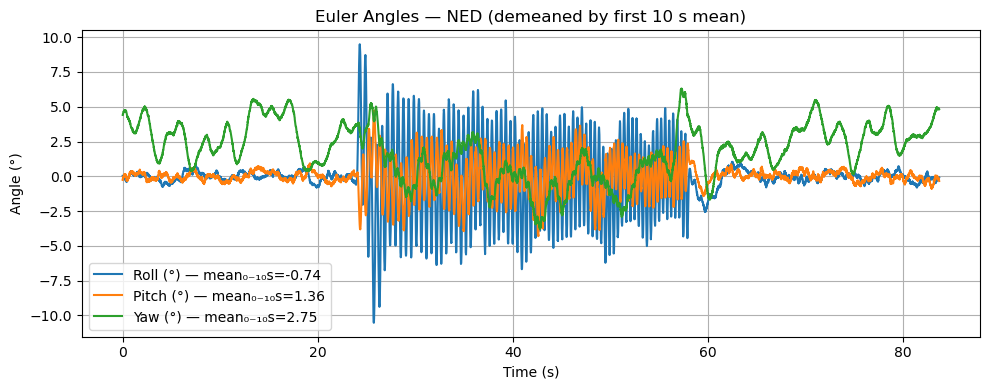

[ENU] First 10s means — Roll: -0.74°, Pitch: -1.36°, Yaw: 87.25°


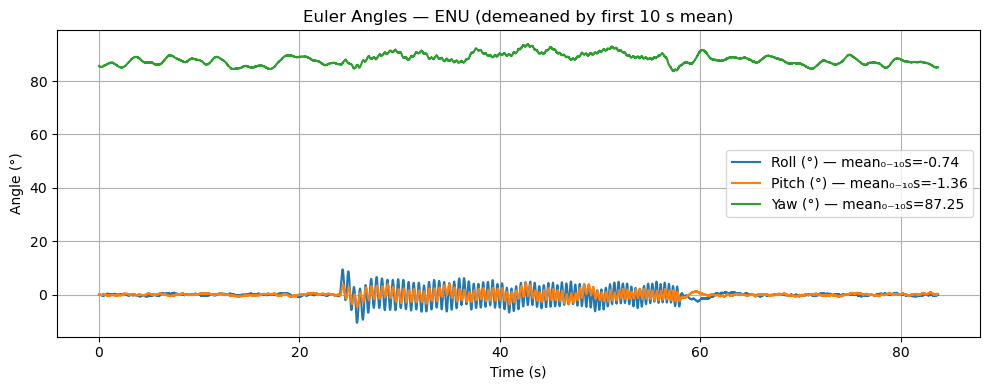

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def demean_first_10s(t, x):
    """Return (x_demeaned, mean_0_10s) using the first 10 s window."""
    t = np.asarray(t); x = np.asarray(x)
    t0 = float(t[0])
    mask10 = (t - t0) <= 10.0
    if not np.any(mask10):  # fallback if trace is shorter than 10 s
        mask10 = np.ones_like(t, dtype=bool)
    m = float(np.nanmean(x[mask10]))
    return x - m, m

def col(df_vicon, *candidates):
    """Pick the first existing column name from candidates."""
    for c in candidates:
        if c in df_vicon.columns:
            return df_vicon[c].to_numpy()
    raise KeyError(f"None of the columns exist: {candidates}")

# ---------- time base ----------
time_s = df_vicon["t_rel"].to_numpy()

# ====================== NED (FRD) angles ======================
roll_ned  = col(df_vicon, "roll_ned_deg",  "roll_deg")
pitch_ned = col(df_vicon, "pitch_ned_deg", "pitch_deg")
yaw_ned   = col(df_vicon, "yaw_ned_deg",   "yaw_deg")

roll_ned_dm,  m_rn = demean_first_10s(time_s, roll_ned)
pitch_ned_dm, m_pn = demean_first_10s(time_s, pitch_ned)
yaw_ned_dm,   m_yn = demean_first_10s(time_s, yaw_ned)   # set to yaw_ned if you prefer not to demean yaw
yaw_ned_dm = yaw_ned      # keep raw yaw

print(f"[NED] First 10s means — Roll: {m_rn:.2f}°, Pitch: {m_pn:.2f}°, Yaw: {m_yn:.2f}°")

plt.figure(figsize=(10,4))
plt.plot(time_s, roll_ned_dm,  label=f"Roll (°) — mean₀₋₁₀s={m_rn:.2f}")
plt.plot(time_s, pitch_ned_dm, label=f"Pitch (°) — mean₀₋₁₀s={m_pn:.2f}")
plt.plot(time_s, yaw_ned_dm,   label=f"Yaw (°) — mean₀₋₁₀s={m_yn:.2f}")
# plt.ylim([-10, 10])
plt.xlabel("Time (s)"); plt.ylabel("Angle (°)")
plt.title("Euler Angles — NED (demeaned by first 10 s mean)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# ====================== ENU (FLU) angles ======================
roll_enu  = col(df_vicon, "roll_enu_deg")
pitch_enu = col(df_vicon, "pitch_enu_deg")
yaw_enu   = col(df_vicon, "yaw_enu_deg")

roll_enu_dm,  m_re = demean_first_10s(time_s, roll_enu)
pitch_enu_dm, m_pe = demean_first_10s(time_s, pitch_enu)
yaw_enu_dm,   m_ye = demean_first_10s(time_s, yaw_enu)
yaw_enu_dm = yaw_enu      # keep raw yaw

print(f"[ENU] First 10s means — Roll: {m_re:.2f}°, Pitch: {m_pe:.2f}°, Yaw: {m_ye:.2f}°")

plt.figure(figsize=(10,4))
plt.plot(time_s, roll_enu_dm,  label=f"Roll (°) — mean₀₋₁₀s={m_re:.2f}")
plt.plot(time_s, pitch_enu_dm, label=f"Pitch (°) — mean₀₋₁₀s={m_pe:.2f}")
plt.plot(time_s, yaw_enu_dm,   label=f"Yaw (°) — mean₀₋₁₀s={m_ye:.2f}")
# plt.ylim([-10, 10])
plt.xlabel("Time (s)"); plt.ylabel("Angle (°)")
plt.title("Euler Angles — ENU (demeaned by first 10 s mean)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


VECHILE ODOMETRY

In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

# --- Load the CSV file ---
df_vo = pd.read_csv("/home/cpsl/px4_ws/data2_26.894khz_log43/csv_out/cpsl_uav_7__fmu__out__vehicle_odometry.csv")

# Show basic info
print("Data summary:")
df_vo.info()

# Display first few rows
df_vo.head()




Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8344 entries, 0 to 8343
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   t                     8344 non-null   float64
 1   t_rel                 8344 non-null   float64
 2   timestamp             8344 non-null   int64  
 3   timestamp_sample      8344 non-null   int64  
 4   pose_frame            8344 non-null   int64  
 5   position              8344 non-null   object 
 6   q                     8344 non-null   object 
 7   velocity_frame        8344 non-null   int64  
 8   velocity              8344 non-null   object 
 9   angular_velocity      8344 non-null   object 
 10  position_variance     8344 non-null   object 
 11  orientation_variance  8344 non-null   object 
 12  velocity_variance     8344 non-null   object 
 13  reset_counter         8344 non-null   int64  
 14  quality               8344 non-null   int64  
dtypes: floa

,t,t_rel,timestamp,timestamp_sample,pose_frame,position,q,velocity_frame,velocity,angular_velocity,position_variance,orientation_variance,velocity_variance,reset_counter,quality
0,1.760993e+09,0.108971,1760992869552066,1760992869551365,1,[ 0.05166778 0.07569915 -0.8365943 ],[0.99909675 0.00833294 0.01185448 0.03994574],1,[-0.00176206 -0.01252674 0.007462 ],[0.00238281 0.00500251 0.01581622],[5.335126e-05 5.334884e-05 5.894959e-05],[6.8162139e-05 4.9552636e-05 2.0704935e-04],[0.0005656 0.0005656 0.00057513],9,0
1,1.760993e+09,0.119366,1760992869562308,1760992869561381,1,[ 0.05165869 0.07556234 -0.83660054],[0.99909073 0.00828244 0.0120505 0.04004898],1,[ 0.00445922 -0.00815453 0.00500344],[0.00365031 0.04250503 0.01432138],[4.8371970e-05 4.8370053e-05 5.3412161e-05],[6.8100060e-05 4.9493949e-05 2.0675309e-04],[0.0005333 0.0005333 0.00054705],9,0
2,1.760993e+09,0.129734,1760992869572110,1760992869571397,1,[ 0.05164832 0.07542633 -0.83660495],[0.99908525 0.00824191 0.01221725 0.04014565],1,[ 0.00743995 -0.01182011 0.00980168],[0.00231944 0.05777849 0.01438128],[5.058357e-05 5.058153e-05 5.561344e-05],[6.8130234e-05 4.9527440e-05 2.0688605e-04],[0.00055047 0.0005505 0.0005584 ],9,0
3,1.760993e+09,0.139037,1760992869582216,1760992869581413,1,[ 0.05164468 0.07529482 -0.83660936],[0.9990802 0.00819315 0.01237708 0.04023042],1,[-0.00295111 -0.01478292 0.01005202],[-0.02130531 0.02163283 0.01871853],[5.2407915e-05 5.2405743e-05 5.8144695e-05],[6.8138368e-05 4.9538681e-05 2.0701795e-04],[0.00055627 0.00055628 0.00057077],9,0
4,1.760993e+09,0.149496,1760992869592409,1760992869591431,1,[ 0.05165799 0.07515684 -0.83660406],[0.9990748 0.00814147 0.01254467 0.04032326],1,[-0.0025676 -0.01099214 0.00685787],[-0.01454734 0.02606265 0.02514273],[4.7801459e-05 4.7799695e-05 5.2557338e-05],[6.8088542e-05 4.9493719e-05 2.0672099e-04],[0.00053049 0.00053052 0.00054266],9,0


In [10]:
def try_cols(df_vo, names):
    """Return the first existing column from `names` as a NumPy array."""
    for n in names:
        if n in df_vo.columns:
            return df_vo[n].to_numpy()
    raise KeyError(f"None of these columns found: {names}")

def _parse_vec_series(series, expected_len):
    """
    Parse a pandas Series whose entries are vector-like strings/lists
    into a (N, expected_len) float array.
    Accepts formats like '[a, b, c]', 'a b c', 'a,b,c', '(a b c)', etc.
    """
    out = []
    for v in series.to_numpy():
        if isinstance(v, (list, tuple, np.ndarray)):
            arr = np.asarray(v, dtype=float)
        else:
            s = str(v).strip()
            # Try Python literal first: "[1, 2, 3]" or "(1, 2, 3)"
            try:
                lit = ast.literal_eval(s)
                arr = np.asarray(lit, dtype=float)
            except Exception:
                # Fallback: strip brackets and split by comma/space
                s = s.strip("[]()")
                if "," in s:
                    parts = [p for p in s.split(",") if p.strip() != ""]
                else:
                    parts = [p for p in s.split() if p.strip() != ""]
                arr = np.asarray(parts, dtype=float)
        if arr.size != expected_len:
            raise ValueError(
                f"Vector parse length mismatch: got {arr.size}, expected {expected_len}. "
                f"First bad entry: {v!r}"
            )
        out.append(arr)
    return np.vstack(out)

def vec3(df_vo, base_names):
    """
    Resolve a 3-vector with many possible naming styles.
    Returns (x, y, z) as 1D float arrays of equal length.
    """
    # Try split-column patterns first
    patterns = [
        lambda b: [f"{b}[0]", f"{b}[1]", f"{b}[2]"],
        lambda b: [f"{b}_0",  f"{b}_1",  f"{b}_2" ],
        lambda b: [f"{b}.x",  f"{b}.y",  f"{b}.z" ],
        lambda b: [f"{b}_x",  f"{b}_y",  f"{b}_z" ],
        lambda b: [f"{b}x",   f"{b}y",   f"{b}z"  ],
    ]
    tried = []
    for b in base_names:
        for pat in patterns:
            cols = pat(b)
            if all(c in df_vo.columns for c in cols):
                return (df_vo[cols[0]].to_numpy(dtype=float),
                        df_vo[cols[1]].to_numpy(dtype=float),
                        df_vo[cols[2]].to_numpy(dtype=float))
        tried.append(b)
        # Single-column fallback: e.g., column named exactly 'position'
        if b in df_vo.columns:
            arr = _parse_vec_series(df_vo[b], 3)  # (N,3)
            return arr[:,0], arr[:,1], arr[:,2]
    raise KeyError(f"Could not resolve vec3 for any base in {tried}. "
                   f"Available columns (first 20): {list(df_vo.columns)[:20]} ...")

def quat4(df_vo, base_names):
    """
    Resolve quaternion in PX4 order [w, x, y, z].
    Returns (qw, qx, qy, qz) as 1D float arrays.
    """
    patterns = [
        lambda b: [f"{b}[0]", f"{b}[1]", f"{b}[2]", f"{b}[3]"],
        lambda b: [f"{b}.w",  f"{b}.x",  f"{b}.y",  f"{b}.z" ],
        lambda b: [f"{b}_w",  f"{b}_x",  f"{b}_y",  f"{b}_z" ],
        lambda b: [f"{b}w",   f"{b}x",   f"{b}y",   f"{b}z"  ],
        lambda b: [f"{b}[w]", f"{b}[x]", f"{b}[y]", f"{b}[z]"],
    ]
    for b in base_names:
        for pat in patterns:
            cols = pat(b)
            if all(c in df_vo.columns for c in cols):
                return (df_vo[cols[0]].to_numpy(dtype=float),
                        df_vo[cols[1]].to_numpy(dtype=float),
                        df_vo[cols[2]].to_numpy(dtype=float),
                        df_vo[cols[3]].to_numpy(dtype=float))
        # Single-column fallback: e.g., column named exactly 'q'
        if b in df_vo.columns:
            arr = _parse_vec_series(df_vo[b], 4)  # (N,4) in PX4 order [w,x,y,z]
            return arr[:,0], arr[:,1], arr[:,2], arr[:,3]

    # Common alternates
    if all(c in df_vo.columns for c in ["qw","qx","qy","qz"]):
        return (df_vo["qw"].to_numpy(dtype=float), df_vo["qx"].to_numpy(dtype=float),
                df_vo["qy"].to_numpy(dtype=float), df_vo["qz"].to_numpy(dtype=float))
    if all(c in df_vo.columns for c in ["q_w","q_x","q_y","q_z"]):
        return (df_vo["q_w"].to_numpy(dtype=float), df_vo["q_x"].to_numpy(dtype=float),
                df_vo["q_y"].to_numpy(dtype=float), df_vo["q_z"].to_numpy(dtype=float))

    raise KeyError(f"Could not resolve quaternion for bases {base_names}. "
                   f"Available columns (first 20): {list(df_vo.columns)[:20]} ...")

def resolve_time_seconds(df_vo):
    """Return time in seconds, relative to first finite sample."""
    cand = ["timestamp_sample", "timestamp", "time_us", "t_us", "t", "time"]
    t_raw = try_cols(df_vo, cand)
    t = np.asarray(t_raw, dtype=float)
    if t.size == 0:
        return t
    mx = np.nanmax(t)
    if mx > 1e12:       # nanoseconds
        t = t * 1e-9
    elif mx > 1e9:      # microseconds
        t = t * 1e-6
    # make relative
    idx = np.flatnonzero(np.isfinite(t))
    if idx.size:
        t = t - t[idx[0]]
    return t

# ---------------- Resolve data ----------------
time_s = resolve_time_seconds(df_vo)

# Positions (NED by PX4 convention) -> create scalar columns
px, py, pz = vec3(df_vo, ["position", "pos", "vehicle_odometry.position", "odom.position"])
df_vo["pos_north"] = px
df_vo["pos_east"]  = py
df_vo["pos_down"]  = pz

# Linear velocity (optional)
have_vel = True
try:
    vx, vy, vz = vec3(df_vo, ["velocity", "vel", "vehicle_odometry.velocity"])
    df_vo["vel_north"] = vx
    df_vo["vel_east"]  = vy
    df_vo["vel_down"]  = vz
except KeyError:
    have_vel = False

# Angular velocity (FRD body), optional
have_rates = True
try:
    wx, wy, wz = vec3(df_vo, ["angular_velocity", "ang_vel", "gyro", "rates", "angularRate"])
    df_vo["p_deg_s"] = np.degrees(wx)
    df_vo["q_deg_s"] = np.degrees(wy)
    df_vo["r_deg_s"] = np.degrees(wz)
except KeyError:
    have_rates = False

# Quaternion -> Euler (FRD body → NED world)  -> create roll_deg/pitch_deg/yaw_deg
qw, qx, qy, qz = quat4(df_vo, ["q", "vehicle_odometry.q", "orientation", "quat"])
sinr_cosp = 2.0*(qw*qx + qy*qz)
cosr_cosp = 1.0 - 2.0*(qx*qx + qy*qy)
roll  = np.arctan2(sinr_cosp, cosr_cosp)

sinp = 2.0*(qw*qy - qz*qx)
pitch = np.where(np.abs(sinp) >= 1.0, np.sign(sinp)*np.pi/2, np.arcsin(sinp))

siny_cosp = 2.0*(qw*qz + qx*qy)
cosy_cosp = 1.0 - 2.0*(qy*qy + qz*qz)
yaw   = np.arctan2(siny_cosp, cosy_cosp)

df_vo["roll_deg"]  = np.degrees(roll)
df_vo["pitch_deg"] = np.degrees(pitch)
df_vo["yaw_deg"]   = np.degrees(np.unwrap(yaw))

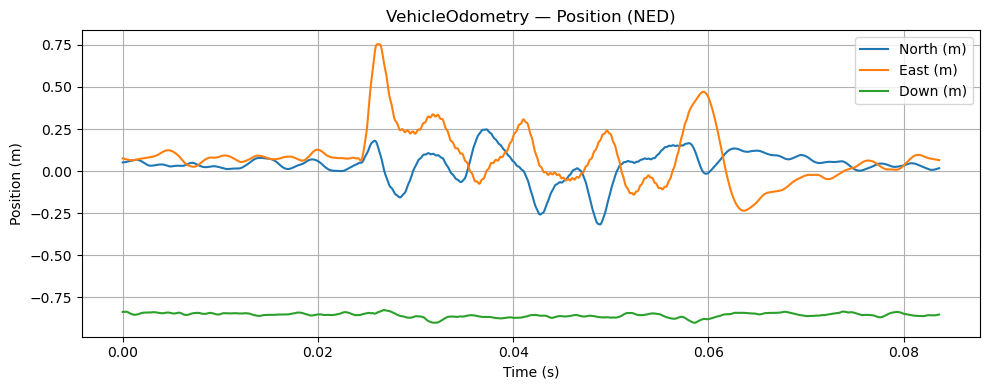

In [11]:
# ===================== PLOTS =====================

# (1) Position (NED)
plt.figure(figsize=(10,4))
plt.plot(time_s, df_vo["pos_north"].to_numpy(), label="North (m)")
plt.plot(time_s, df_vo["pos_east"].to_numpy(),  label="East (m)")
plt.plot(time_s, df_vo["pos_down"].to_numpy(),  label="Down (m)")
plt.xlabel("Time (s)"); plt.ylabel("Position (m)")
plt.title("VehicleOdometry — Position (NED)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


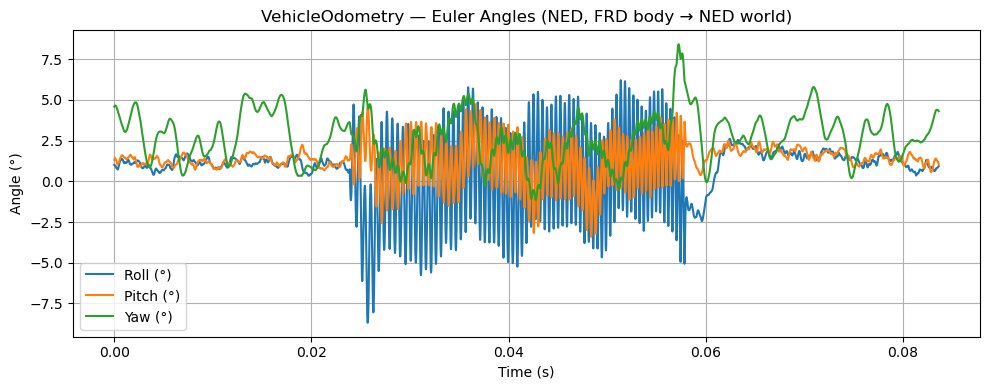

In [12]:
# (2) Euler angles (deg) — robust plotting (no axes handle; unique var names)
roll_deg_eul  = np.asarray(df_vo["roll_deg"],  dtype=float)
pitch_deg_eul = np.asarray(df_vo["pitch_deg"], dtype=float)
yaw_deg_eul   = np.asarray(df_vo["yaw_deg"],   dtype=float)

# Ensure same length
n_eul = min(time_s.size, roll_deg_eul.size, pitch_deg_eul.size, yaw_deg_eul.size)
t_eul = np.asarray(time_s[:n_eul], dtype=float)
roll_deg_eul  = roll_deg_eul[:n_eul]
pitch_deg_eul = pitch_deg_eul[:n_eul]
yaw_deg_eul   = yaw_deg_eul[:n_eul]

# Drop NaNs/Infs consistently
mask_eul = (
    np.isfinite(t_eul) &
    np.isfinite(roll_deg_eul) &
    np.isfinite(pitch_deg_eul) &
    np.isfinite(yaw_deg_eul)
)
t_eul          = t_eul[mask_eul]
roll_deg_eul   = roll_deg_eul[mask_eul]
pitch_deg_eul  = pitch_deg_eul[mask_eul]
yaw_deg_eul    = yaw_deg_eul[mask_eul]

# Plot using pyplot only
plt.figure(figsize=(10, 4))
plt.plot(t_eul, roll_deg_eul,  label="Roll (°)")
plt.plot(t_eul, pitch_deg_eul, label="Pitch (°)")
plt.plot(t_eul, yaw_deg_eul,   label="Yaw (°)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (°)")
plt.title("VehicleOdometry — Euler Angles (NED, FRD body → NED world)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


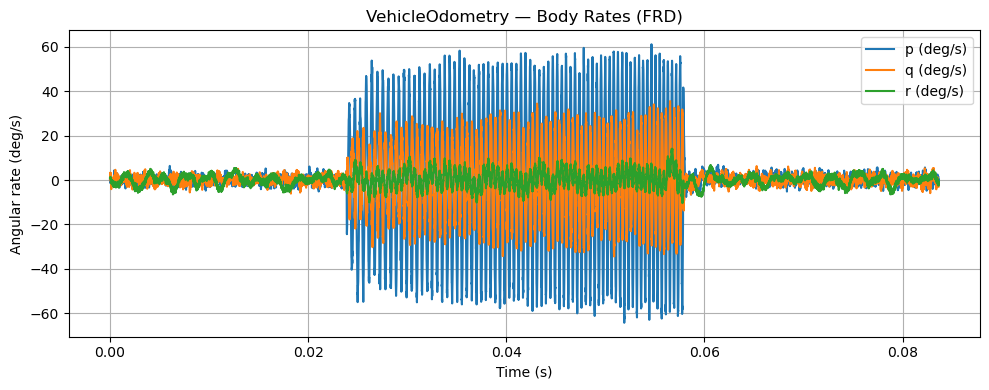

In [13]:
# (3) Angular rates (deg/s) — robust plotting (no axes handle; unique var names)
if have_rates and all(c in df_vo.columns for c in ["p_deg_s", "q_deg_s", "r_deg_s"]):
    p_deg_rates = np.asarray(df_vo["p_deg_s"], dtype=float)
    q_deg_rates = np.asarray(df_vo["q_deg_s"], dtype=float)
    r_deg_rates = np.asarray(df_vo["r_deg_s"], dtype=float)

    # Align series lengths
    n_rates = min(time_s.size, p_deg_rates.size, q_deg_rates.size, r_deg_rates.size)
    t_rates = np.asarray(time_s[:n_rates], dtype=float)
    p_deg_rates = p_deg_rates[:n_rates]
    q_deg_rates = q_deg_rates[:n_rates]
    r_deg_rates = r_deg_rates[:n_rates]

    # Drop rows with NaNs/Infs
    mask_rates = (
        np.isfinite(t_rates) &
        np.isfinite(p_deg_rates) &
        np.isfinite(q_deg_rates) &
        np.isfinite(r_deg_rates)
    )
    t_rates      = t_rates[mask_rates]
    p_deg_rates  = p_deg_rates[mask_rates]
    q_deg_rates  = q_deg_rates[mask_rates]
    r_deg_rates  = r_deg_rates[mask_rates]

    # Plot using pyplot only
    plt.figure(figsize=(10, 4))
    plt.plot(t_rates, p_deg_rates, label="p (deg/s)")
    plt.plot(t_rates, q_deg_rates, label="q (deg/s)")
    plt.plot(t_rates, r_deg_rates, label="r (deg/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular rate (deg/s)")
    plt.title("VehicleOdometry — Body Rates (FRD)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No angular-rate columns found; skipped body-rate plot.")


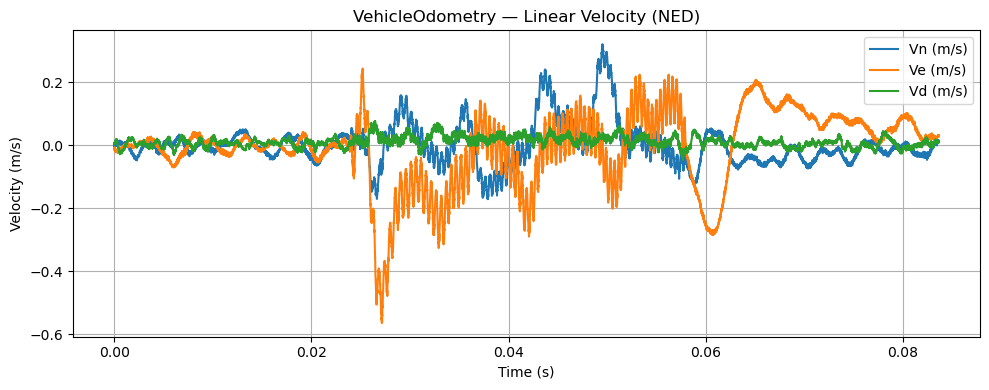

In [14]:
# (4) Linear velocity (NED, m/s) — robust plotting (no axes handle; unique var names)
if have_vel and all(c in df_vo.columns for c in ["vel_north", "vel_east", "vel_down"]):
    vn_vel = np.asarray(df_vo["vel_north"], dtype=float)
    ve_vel = np.asarray(df_vo["vel_east"],  dtype=float)
    vd_vel = np.asarray(df_vo["vel_down"],  dtype=float)

    # Align series lengths
    n_vel = min(time_s.size, vn_vel.size, ve_vel.size, vd_vel.size)
    t_vel = np.asarray(time_s[:n_vel], dtype=float)
    vn_vel, ve_vel, vd_vel = vn_vel[:n_vel], ve_vel[:n_vel], vd_vel[:n_vel]

    # Drop rows with NaNs/Infs
    mask_vel = (
        np.isfinite(t_vel) &
        np.isfinite(vn_vel) &
        np.isfinite(ve_vel) &
        np.isfinite(vd_vel)
    )
    t_vel  = t_vel[mask_vel]
    vn_vel = vn_vel[mask_vel]
    ve_vel = ve_vel[mask_vel]
    vd_vel = vd_vel[mask_vel]

    # Plot using pyplot only
    plt.figure(figsize=(10, 4))
    plt.plot(t_vel, vn_vel, label="Vn (m/s)")
    plt.plot(t_vel, ve_vel, label="Ve (m/s)")
    plt.plot(t_vel, vd_vel, label="Vd (m/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.title("VehicleOdometry — Linear Velocity (NED)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No velocity columns found; skipped linear-velocity plot.")


SENSOR_COMBINED

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

# --- Load the CSV file ---
df_sensor = pd.read_csv("/home/cpsl/px4_ws/data2_26.894khz_log43/csv_out/cpsl_uav_7__fmu__out__sensor_combined.csv")

# Show basic info
print("Data summary:")
df_sensor.info()

# Display first few rows
df_sensor.head()




Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   t                                 8364 non-null   float64
 1   t_rel                             8364 non-null   float64
 2   timestamp                         8364 non-null   int64  
 3   gyro_rad                          8364 non-null   object 
 4   gyro_integral_dt                  8364 non-null   int64  
 5   accelerometer_timestamp_relative  8364 non-null   int64  
 6   accelerometer_m_s2                8364 non-null   object 
 7   accelerometer_integral_dt         8364 non-null   int64  
 8   accelerometer_clipping            8364 non-null   int64  
 9   gyro_clipping                     8364 non-null   int64  
 10  accel_calibration_count           8364 non-null   int64  
 11  gyro_calibration_count            8364 non-null   int64

,t,t_rel,timestamp,gyro_rad,gyro_integral_dt,accelerometer_timestamp_relative,accelerometer_m_s2,accelerometer_integral_dt,accelerometer_clipping,gyro_clipping,accel_calibration_count,gyro_calibration_count
0,1.760993e+09,0.114244,1760992869556373,[-0.02643454 0.0353352 0.02559184],2504,0,[-1.8929579 -0.60209274 -9.630308 ],2504,0,0,1,1
1,1.760993e+09,0.123868,1760992869566389,[-0.00105638 0.00707928 0.02342809],2504,0,[-1.031866 -0.7319165 -9.443129 ],2504,0,0,1,1
2,1.760993e+09,0.133783,1760992869576406,[-0.01110258 0.03595878 0.01811097],2505,0,[-1.3178172 0.5352227 -9.255073 ],2505,0,0,1,1
3,1.760993e+09,0.143698,1760992869586423,[-0.00398418 0.04146807 0.01728746],2505,0,[ 0.65181935 -0.35196286 -10.948695 ],2505,0,0,1,1
4,1.760993e+09,0.153963,1760992869596439,[0.00057397 0.00518208 0.00955627],2503,0,[ 3.2755883 0.15583482 -8.281063 ],2503,0,0,1,1


In [16]:
# 2) Time base in seconds  ---------------------------------------------------
def get_time_seconds(df_sensor):
    # Prefer t_rel if available; otherwise infer µs
    if "t_rel" in df_sensor.columns:
        t = df_sensor["t_rel"].to_numpy(dtype=float)
        return t - t[0]
    for c in ["timestamp_sample", "timestamp", "time_us", "t_us"]:
        if c in df_sensor.columns:
            t = df_sensor[c].to_numpy(dtype=float)
            return (t - t[0]) * 1e-6
    raise KeyError("No time column found (t_rel/timestamp_sample/timestamp/time_us/t_us).")

time_s = get_time_seconds(df_sensor)


In [17]:
# 3) Vector column parser  ---------------------------------------------------
def split_vec_col(series: pd.Series):
    """
    Convert strings like "[a b c]" or "[a, b, c]" into 3 float arrays.
    Uses numpy.fromstring so it's robust to spaces/commas.
    """
    xs, ys, zs = [], [], []
    for s in series.astype(str):
        vals = np.fromstring(s.strip('[]'), sep=' ')
        if vals.size < 3:
            vals = np.fromstring(s.strip('[]'), sep=',')
        if vals.size >= 3:
            xs.append(vals[0]); ys.append(vals[1]); zs.append(vals[2])
        else:
            xs.append(np.nan); ys.append(np.nan); zs.append(np.nan)
    return np.array(xs, float), np.array(ys, float), np.array(zs, float)

In [18]:
# 4) Extract IMU signals  ----------------------------------------------------
# PX4 sensor_combined typically stores these as bracketed strings
ax, ay, az = split_vec_col(df_sensor["accelerometer_m_s2"])
gx, gy, gz = split_vec_col(df_sensor["gyro_rad"])

# Convert gyro rad/s -> deg/s for readability
p_deg_s = np.degrees(gx)
q_deg_s = np.degrees(gy)
r_deg_s = np.degrees(gz)


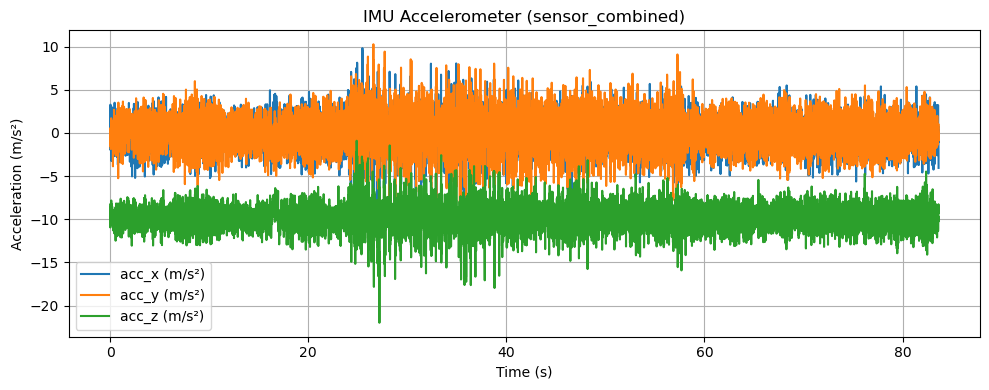

In [19]:

# 5) Plots (each chart in its own figure)  ----------------------------------
plt.figure(figsize=(10, 4))
plt.plot(time_s, ax, label="acc_x (m/s²)")
plt.plot(time_s, ay, label="acc_y (m/s²)")
plt.plot(time_s, az, label="acc_z (m/s²)")
plt.xlabel("Time (s)"); plt.ylabel("Acceleration (m/s²)")
plt.title("IMU Accelerometer (sensor_combined)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


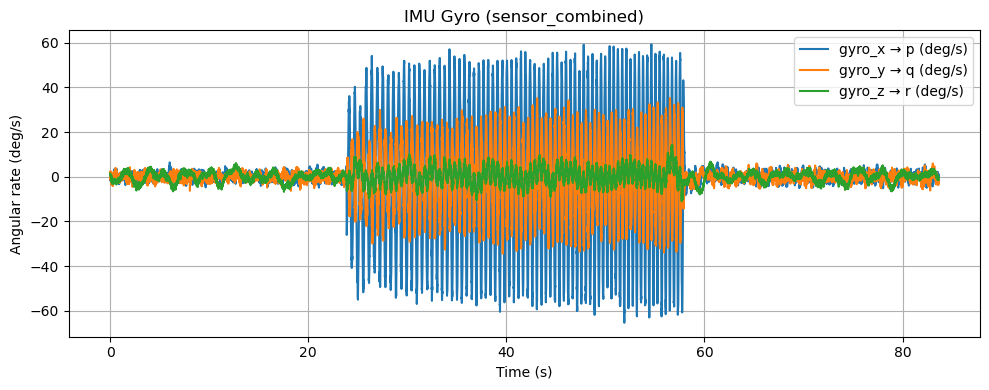

In [20]:

plt.figure(figsize=(10, 4))
plt.plot(time_s, p_deg_s, label="gyro_x → p (deg/s)")
plt.plot(time_s, q_deg_s, label="gyro_y → q (deg/s)")
plt.plot(time_s, r_deg_s, label="gyro_z → r (deg/s)")
plt.xlabel("Time (s)"); plt.ylabel("Angular rate (deg/s)")
plt.title("IMU Gyro (sensor_combined)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

Overall

In [21]:
import numpy as np
import ast  # only needed if you use vector parsers elsewhere

def time_seconds(df):
    """Pick a time column, convert to seconds, and make relative to first sample."""
    for c in ("t_rel", "timestamp_sample", "timestamp", "time_us"):
        if c in df.columns:
            t = df[c].to_numpy(dtype=float)
            if c in ("timestamp_sample", "timestamp", "time_us"):
                t *= 1e-6  # µs→s
            idx = np.flatnonzero(np.isfinite(t))
            return t - t[idx[0]] if idx.size else t
    raise KeyError("No time column found.")

def interp_to_ref(t_ref, t_src, y_src):
    """
    Interpolate y_src(t_src) onto t_ref.
    Cleans NaNs, sorts, deduplicates t_src; pads NaN outside range.
    Also trims if t_src and y_src lengths differ.
    """
    t_ref = np.asarray(t_ref, dtype=float)
    t_src = np.asarray(t_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)

    # If lengths differ, trim to the shorter one (keeps time/data pairing)
    if t_src.shape[0] != y_src.shape[0]:
        n = min(t_src.shape[0], y_src.shape[0])
        t_src = t_src[:n]
        y_src = y_src[:n]

    # Remove non-finite
    m = np.isfinite(t_src) & np.isfinite(y_src)
    t_src = t_src[m]; y_src = y_src[m]
    if t_src.size < 2:
        return np.full_like(t_ref, np.nan, dtype=float)

    # Sort by time
    order = np.argsort(t_src)
    t_src = t_src[order]; y_src = y_src[order]

    # Deduplicate times (keep first occurrence)
    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_ref, t_unique, y_unique, left=np.nan, right=np.nan)

# ---------------- time from each source ----------------
t_vo     = time_seconds(df_vo)       # vehicle_odometry CSV
t_vicon  = time_seconds(df_vicon)    # Vicon CSV
t_sensor = time_seconds(df_sensor)   # sensor_combined CSV (for p_deg_rates)

# choose a common reference time axis (e.g., sensor_combined)
t_ref = t_sensor

# ---------------- interpolate each signal to t_ref ----------------
# From Vicon:
pitch_ned_vic_i = interp_to_ref(t_ref, t_vicon, pitch_ned_dm.astype(float))
roll_ned_vic_i  = interp_to_ref(t_ref, t_vicon, roll_ned_dm.astype(float))
east_vic_i      = interp_to_ref(t_ref, t_vicon, east_dm.astype(float))

# From vehicle_odometry:
roll_vo_i = interp_to_ref(t_ref, t_vo, df_vo["roll_deg"].to_numpy(dtype=float))
east_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pos_east"].to_numpy(dtype=float))

# From sensor_combined (ensure same base as t_sensor):
p_deg_rates_i = interp_to_ref(t_ref, t_sensor, p_deg_rates.astype(float))

# Sanity print
print("Shapes:",
      "t_ref", t_ref.shape,
      "pitch_ned_vic_i", pitch_ned_vic_i.shape,
      "roll_ned_vic_i", roll_ned_vic_i.shape,
      "roll_vo_i", roll_vo_i.shape,
      "east_vo_i", east_vo_i.shape,
      "east_vic_i", east_vic_i.shape,
      "p_deg_rates_i", p_deg_rates_i.shape)


Shapes: t_ref (8364,) pitch_ned_vic_i (8364,) roll_ned_vic_i (8364,) roll_vo_i (8364,) east_vo_i (8364,) east_vic_i (8364,) p_deg_rates_i (8364,)


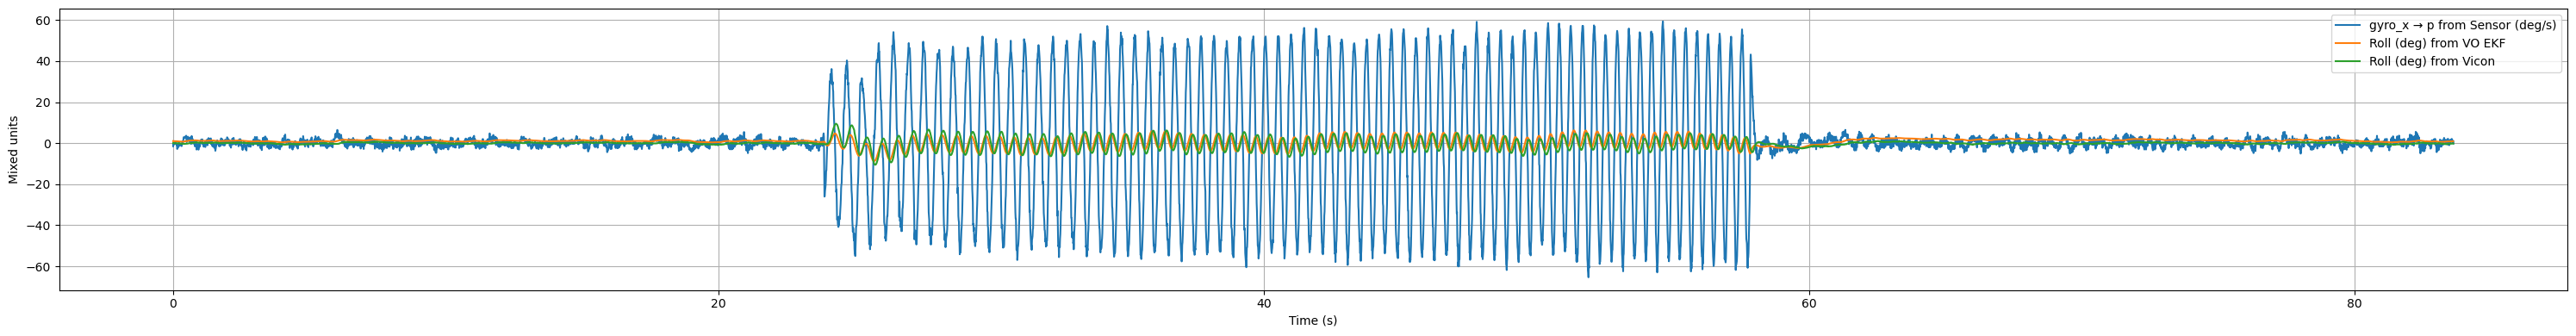

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 4))
plt.plot(time_s, p_deg_s,    label="gyro_x → p from Sensor (deg/s)")
# plt.plot(time_s, p_deg_rates_i,    label="gyro_x → p from VO (deg/s)")
plt.plot(time_s, roll_vo_i,  label="Roll (deg) from VO EKF")
plt.plot(time_s, roll_ned_vic_i, label="Roll (deg) from Vicon")
# plt.plot(time_s, 10*east_vo_i,  label="East from VO (dm)")
# plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)")
# plt.ylim(-10, 10)
plt.xlabel("Time (s)"); plt.ylabel("Mixed units")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [23]:
# ---------- Interpolate NORTH & PITCH to t_ref ----------

# ---- Vicon sources (robust fallbacks) ----
# north: use demeaned if you already computed it; else raw pos_north
if 'north_dm' in globals():
    north_vicon_src = np.asarray(north_dm, dtype=float)
elif "pos_north" in df_vicon.columns:
    north_vicon_src = df_vicon["pos_north"].to_numpy(dtype=float)
else:
    raise KeyError("Need Vicon north: provide `north_dm` or df_vicon['pos_north'].")

# pitch: use your demeaned pitch if present; else look for a Vicon pitch col (deg)
if 'pitch_ned_dm' in globals():
    pitch_vicon_src_deg = np.asarray(pitch_ned_dm, dtype=float)
elif "pitch_deg" in df_vicon.columns:
    pitch_vicon_src_deg = df_vicon["pitch_deg"].to_numpy(dtype=float)
else:
    raise KeyError("Need Vicon pitch: provide `pitch_ned_dm` or df_vicon['pitch_deg'].")

# Interpolate Vicon to the common time base
north_vic_i  = interp_to_ref(t_ref, t_vicon, north_vicon_src)
pitch_vic_i  = interp_to_ref(t_ref, t_vicon, pitch_vicon_src_deg)

# ---- VO (vehicle_odometry) sources ----
if "pos_north" not in df_vo.columns:
    raise KeyError("df_vo must contain 'pos_north' for VO north position.")
if "pitch_deg" not in df_vo.columns:
    raise KeyError("df_vo must contain 'pitch_deg' (computed earlier from quaternion).")

north_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pos_north"].to_numpy(dtype=float))
pitch_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pitch_deg"].to_numpy(dtype=float))

# Alias for plotting to match your earlier code
time_s = np.asarray(t_ref, dtype=float)

# Quick sanity
print("Interpolated arrays:")
print("  north_vic_i:", north_vic_i.shape, " pitch_vic_i:", pitch_vic_i.shape)
print("  north_vo_i :", north_vo_i.shape,  " pitch_vo_i :", pitch_vo_i.shape)


Interpolated arrays:
  north_vic_i: (8364,)  pitch_vic_i: (8364,)
  north_vo_i : (8364,)  pitch_vo_i : (8364,)


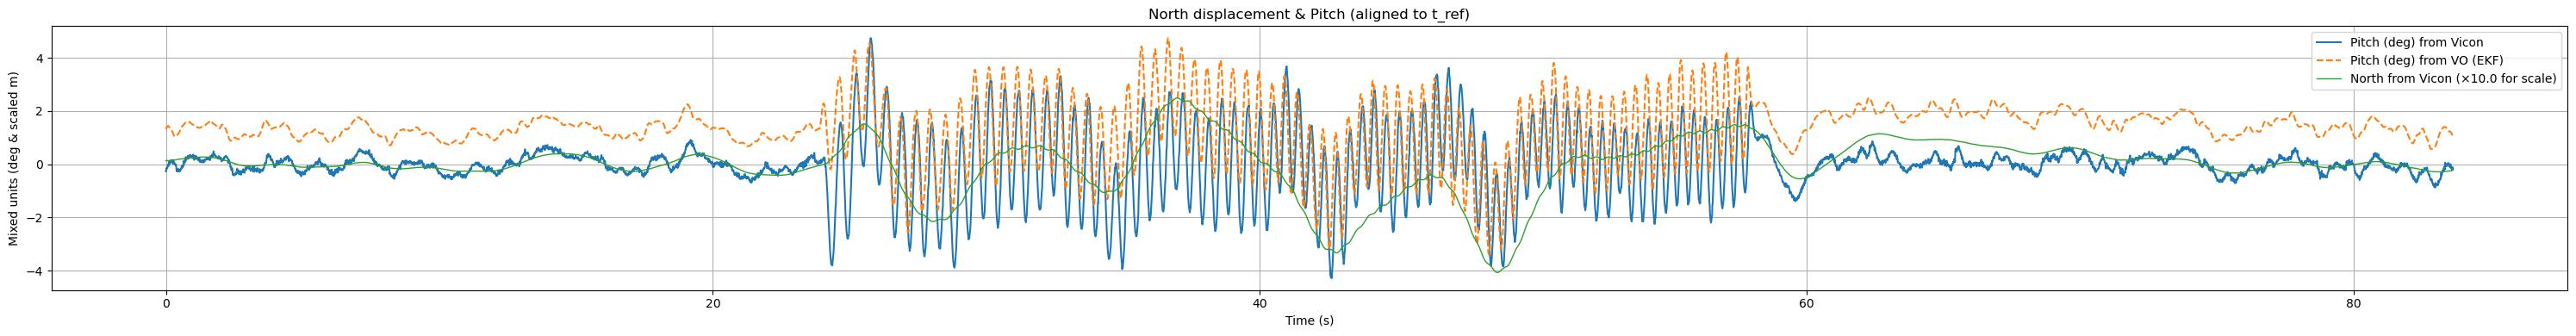

In [25]:
import matplotlib.pyplot as plt

SCALE_NORTH = 10.0  # scale meters -> decimeters for overplotting with degrees

plt.figure(figsize=(30, 4))
plt.plot(time_s, pitch_vic_i,        label="Pitch (deg) from Vicon", lw=1.5)
plt.plot(time_s, pitch_vo_i,         label="Pitch (deg) from VO (EKF)", lw=1.5, ls='--')
plt.plot(time_s, SCALE_NORTH*north_vic_i, label=f"North from Vicon (×{SCALE_NORTH} for scale)", lw=1.0)
# plt.plot(time_s, SCALE_NORTH*north_vo_i,  label=f"North from VO (×{SCALE_NORTH} for scale)",   lw=1.0, ls='--')

plt.xlabel("Time (s)")
plt.ylabel("Mixed units (deg & scaled m)")
plt.title("North displacement & Pitch (aligned to t_ref)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== Core helpers =====================

def moving_average(x, win_samples: int):
    """Simple centered moving average (same-size output)."""
    win = int(max(1, win_samples))
    if win == 1:
        return np.asarray(x, float)
    k = np.ones(win, float) / win
    return np.convolve(np.asarray(x, float), k, mode="same")

def interp_to_ref(t_ref, t_src, y_src):
    """
    Interpolate y_src(t_src) onto t_ref.
    Cleans NaNs, sorts, deduplicates times; pads with NaN outside range.
    """
    t_ref = np.asarray(t_ref, float)
    t_src = np.asarray(t_src, float)
    y_src = np.asarray(y_src, float)

    # align lengths if a logger dropped samples in one of the arrays
    n = min(t_src.size, y_src.size)
    t_src, y_src = t_src[:n], y_src[:n]

    m = np.isfinite(t_src) & np.isfinite(y_src)
    t_src, y_src = t_src[m], y_src[m]
    if t_src.size < 2:
        return np.full_like(t_ref, np.nan, float)

    order = np.argsort(t_src)
    t_src, y_src = t_src[order], y_src[order]

    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_ref, t_unique, y_unique, left=np.nan, right=np.nan)

def cycle_bounds_from_signal(
    t, y, *, osc_smooth_s=0.03, trend_s=0.50
):
    """
    Detect oscillation cycles via positive-going zero crossings of a
    smoothed+detrended version of y.

    Returns:
      tc      : (K,) time at center of each cycle
      bounds  : list[(i0, i1)] index bounds over ORIGINAL arrays (inclusive end)
      trend   : slow baseline used for detrending (same length as y)
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), [], np.full_like(t, np.nan, float)

    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return np.array([]), [], np.full_like(t, np.nan, float)

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s   / dt)) | 1)   # force odd

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    s = np.sign(osc)
    s[s == 0] = 1
    zc_pos = np.where((s[:-1] < 0) & (s[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), [], trend

    tc, bounds = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        # use interior of each cycle [i0+1, i1]
        if (i1 - i0) >= 2:
            bounds.append((i0+1, i1))
            tc.append(0.5*(t[i0+1] + t[i1]))

    return np.asarray(tc), bounds, trend

def per_cycle_mean_from_bounds(y, bounds):
    """Return per-cycle mean of y over the provided bounds list[(i0,i1)]."""
    y = np.asarray(y, float)
    means = []
    for i0, i1 in bounds:
        seg = y[i0:i1+1]
        means.append(np.nan if seg.size == 0 else float(np.nanmean(seg)))
    return np.asarray(means, float)

# ===================== Plotting APIs =====================

def plot_cycle_mean(
    t, y, *,
    label="signal",
    color=None,
    use_reference=None,
    osc_smooth_s=0.03,
    trend_s=0.50,
    show_raw=True,
    raw_alpha=0.25,
    step_kwargs=None,
    scatter_kwargs=None,
):
    """
    Plot raw series (optional) plus per-cycle means (as steps+markers).
    If use_reference is provided as a (t_ref, y_ref) pair, cycles are segmented
    on that reference but means are computed on y. Otherwise y self-segments.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    n = min(t.size, y.size)
    t, y = t[:n], y[:n]

    if use_reference is None:
        tc, bounds, _ = cycle_bounds_from_signal(t, y, osc_smooth_s=osc_smooth_s, trend_s=trend_s)
    else:
        t_ref, y_ref = use_reference
        t_ref = np.asarray(t_ref, float)
        y_ref = np.asarray(y_ref, float)
        nref  = min(t_ref.size, y_ref.size)
        t_ref, y_ref = t_ref[:nref], y_ref[:nref]
        tc, bounds, _ = cycle_bounds_from_signal(t_ref, y_ref, osc_smooth_s=osc_smooth_s, trend_s=trend_s)

        # Convert reference time centers to indices on our t for plotting markers/steps
        # (we'll just use tc as x for the means; means are computed from bounds on y)
    means = per_cycle_mean_from_bounds(y, bounds)

    # Plot
    if show_raw:
        plt.plot(t, y, lw=0.9, alpha=raw_alpha, color=color, label=f"{label} (raw)")

    step_kwargs  = {} if step_kwargs is None else dict(step_kwargs)
    scatter_kwargs = {} if scatter_kwargs is None else dict(scatter_kwargs)

    plt.step(tc, means, where="mid", lw=2.0, color=color, label=f"{label} — cycle mean", **step_kwargs)
    plt.scatter(tc, means, s=20, zorder=3, color=color, **scatter_kwargs)

    return tc, means  # handy if you want to compute further stats

def plot_multi_cycle_means(
    t, series_dict,
    *,
    reference_label=None,
    independent=False,
    osc_smooth_s=0.03,
    trend_s=0.50,
    show_raw=True,
):
    """
    series_dict: {label: y}
    If independent=False: cycles are taken from the reference (first key or reference_label).
    If independent=True: each series is segmented independently.
    """
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)

    if not independent:
        if reference_label is None:
            reference_label = next(iter(series_dict.keys()))
        tcref, bounds, _ = cycle_bounds_from_signal(
            t, series_dict[reference_label], osc_smooth_s=osc_smooth_s, trend_s=trend_s
        )

        for i, (lbl, y) in enumerate(series_dict.items()):
            color = None if colors is None else colors[i % len(colors)]
            if show_raw:
                plt.plot(t[:len(y)], y[:len(y)], lw=0.9, alpha=0.25, color=color, label=f"{lbl} (raw)")
            means = per_cycle_mean_from_bounds(y, bounds)
            plt.step(tcref, means, where="mid", lw=2.0, color=color, label=f"{lbl} — cycle mean")
            plt.scatter(tcref, means, s=20, zorder=3, color=color)
        return

    # independent segmentation per series
    for i, (lbl, y) in enumerate(series_dict.items()):
        color = None if colors is None else colors[i % len(colors)]
        if show_raw:
            plt.plot(t[:len(y)], y[:len(y)], lw=0.9, alpha=0.25, color=color, label=f"{lbl} (raw)")
        tc, bounds, _ = cycle_bounds_from_signal(t, y, osc_smooth_s=osc_smooth_s, trend_s=trend_s)
        means = per_cycle_mean_from_bounds(y, bounds)
        plt.step(tc, means, where="mid", lw=2.0, color=color, label=f"{lbl} — cycle mean")
        plt.scatter(tc, means, s=20, zorder=3, color=color)


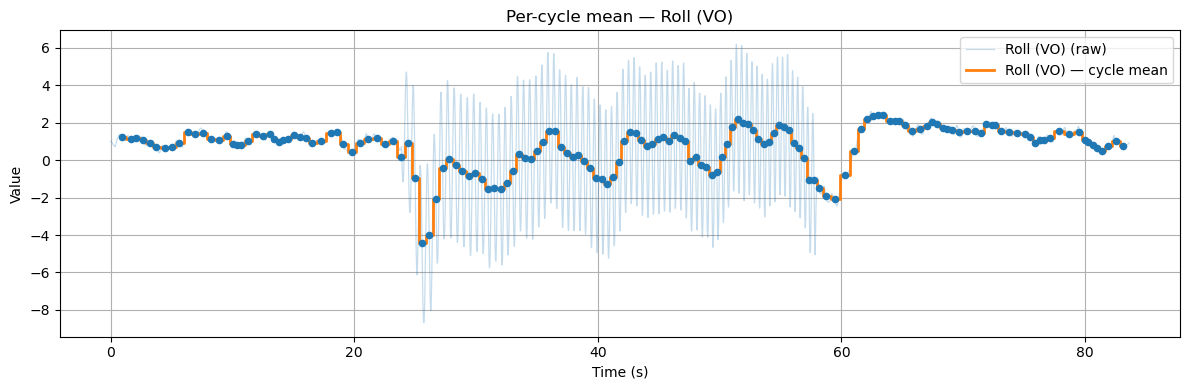

In [29]:
plt.figure(figsize=(12,4))
tc_roll, m_roll = plot_cycle_mean(time_s, roll_vo_i, label="Roll (VO)", osc_smooth_s=0.04, trend_s=0.6)
plt.xlabel("Time (s)"); plt.ylabel("Value"); plt.title("Per-cycle mean — Roll (VO)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


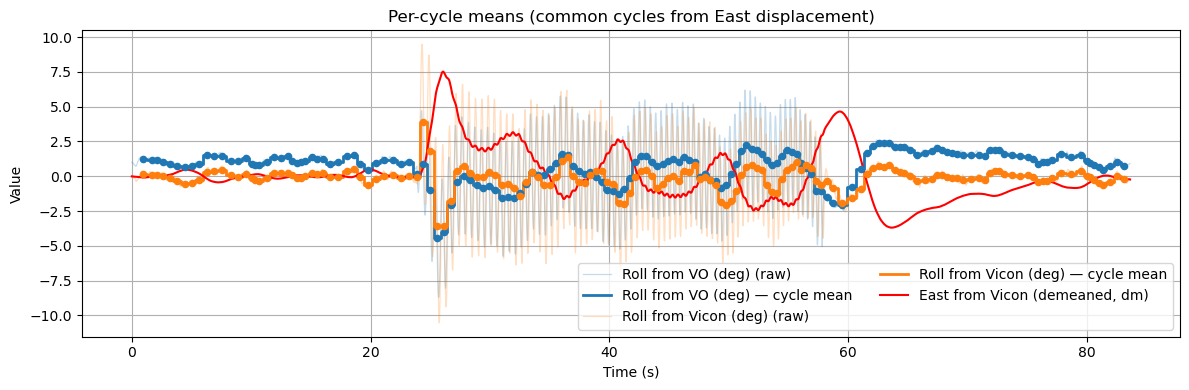

In [30]:
plt.figure(figsize=(12,4))
plot_multi_cycle_means(
    time_s,
    {
        # "East from Vicon (dm)": east_vic_i,
        "Roll from VO (deg)":    roll_vo_i,
        "Roll from Vicon (deg)": roll_ned_vic_i,
    },
    # reference_label="East from Vicon (dm)",
    osc_smooth_s=0.04, trend_s=0.6, show_raw=True
)
plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)", color="red")
plt.xlabel("Time (s)"); plt.ylabel("Value")
plt.title("Per-cycle means (common cycles from East displacement)")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout(); plt.show()


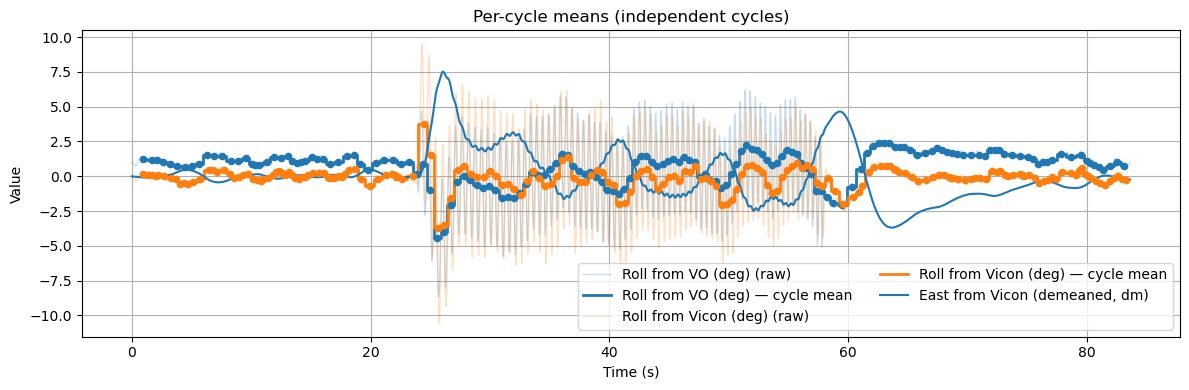

In [31]:
plt.figure(figsize=(12,4))
plot_multi_cycle_means(
    time_s,
    {
        "Roll from VO (deg)":    roll_vo_i,
        "Roll from Vicon (deg)": roll_ned_vic_i,
        # "Pitch from Vicon (deg)": pitch_ned_vic_i,
    },
    independent=True,
    osc_smooth_s=0.04, trend_s=0.6, show_raw=True
)
plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)")
plt.xlabel("Time (s)"); plt.ylabel("Value")
plt.title("Per-cycle means (independent cycles)")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout(); plt.show()
